### Integrantes: Santiago Parada - Francisco Castro - Natalia Rodriguez - David Cifuentes

# 02 - Rol 2: Segmentación por Partición
**Proyecto Retador: Patrones Invisibles** - ML No Supervisado - Universidad de La Sabana · 2026-II

**Pregunta de UrbanMove:** ¿qué perfiles de viaje existen realmente en la operación, y cuáles registros son atípicos y deben tratarse aparte?

**Plan del bloque:**

| Sección | Contenido |
|---|---|
| 1 | Espacio de características y estandarización |
| 2 | K-means: selección de K con codo y silueta |
| 3 | Clustering jerárquico (Ward) y comparación con K-means |
| 4 | DBSCAN: selección de épsilon con gráfica k-distancia y detección de ruido |
| 5 | Métricas de validación de los tres métodos |
| 6 | Perfiles operativos y tratamiento del ruido |

Datos de entrada: `muestra_50k.csv`, generada en `00_datos.ipynb`.

## 0. Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, silhouette_samples, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

SEMILLA = 42
rng = np.random.default_rng(SEMILLA)
RUTA_DATOS = '../data'

muestra = pd.read_csv(f'{RUTA_DATOS}/muestra_50k.csv', parse_dates=['pickup_datetime'])
ORDEN_FRANJAS = ['madrugada', 'pico_am', 'valle', 'pico_pm', 'noche']
muestra['franja'] = pd.Categorical(muestra.franja, categories=ORDEN_FRANJAS, ordered=True)
N = len(muestra)
print(f'{N:,} viajes cargados')

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.rcParams['figure.dpi'] = 110

50,000 viajes cargados


## 1. Espacio de características

Se segmentan viajes, no zonas. Cada viaje se describe con cinco variables:

| Variable | Razón |
|---|---|
| log(1 + distancia_km) | La distancia está muy sesgada a la derecha (muchos viajes cortos, pocos al aeropuerto). El logaritmo evita que los viajes largos dominen la distancia euclidiana |
| log(1 + duración_min) | Mismo argumento que la distancia |
| velocidad_kmh | Separa viajes fluidos de viajes en congestión, aunque recorran lo mismo |
| sen(2πh/24), cos(2πh/24) | La hora es cíclica: las 23:00 y las 0:00 están a una hora de distancia, no a 23. Con seno y coseno la hora queda sobre un círculo y esa distancia se respeta |

**Estandarización:** K-means y DBSCAN se basan en distancias, así que una variable con rango grande dominaría a las demás. `StandardScaler` deja cada variable con media 0 y desviación 1, de modo que todas pesan igual.

In [2]:
VARIABLES = ['log_dist', 'log_dur', 'velocidad_kmh', 'hora_sen', 'hora_cos']

muestra['log_dist'] = np.log1p(muestra.distancia_km)
muestra['log_dur'] = np.log1p(muestra.duracion_min)
muestra['hora_sen'] = np.sin(2 * np.pi * muestra.hora / 24)
muestra['hora_cos'] = np.cos(2 * np.pi * muestra.hora / 24)

escalador = StandardScaler()
X = escalador.fit_transform(muestra[VARIABLES])
print('Matriz de características:', X.shape)
pd.DataFrame(X, columns=VARIABLES).describe().T[['mean', 'std', 'min', 'max']]

Matriz de características: (50000, 5)


,mean,std,min,max
log_dist,0.000,1.000,-1.906,3.996
log_dur,-0.000,1.000,-2.761,3.687
velocidad_kmh,-0.000,1.000,-1.901,7.168
hora_sen,-0.000,1.000,-1.183,1.795
hora_cos,0.000,1.000,-1.300,1.528


## 2. K-means: selección de K

K-means busca K centroides que minimicen la inercia, es decir, la suma de distancias al cuadrado de cada punto a su centroide. K no se conoce de antemano, así que se justifica con dos criterios independientes:

**Método del codo:** la inercia siempre baja al aumentar K (con K = N sería cero), así que no sirve buscar el mínimo. Se busca el punto donde deja de bajar rápido, porque a partir de ahí cada cluster nuevo aporta poco.

**Índice de Davies-Bouldin:** compara la dispersión interna de cada cluster con la distancia a su cluster más parecido. Es menor cuando los grupos son compactos y están lejos entre sí, así que se busca el mínimo.

**Índice de silueta:** para cada punto compara su distancia media a su propio cluster (a) con la del cluster vecino más cercano (b), mediante (b - a) / max(a, b). Va de -1 a 1: cerca de 1 el punto está bien asignado, cerca de 0 está en la frontera y negativo indica mala asignación. Se calcula sobre una submuestra de 10 000 puntos porque el cálculo completo es cuadrático en el número de viajes.

In [3]:
K_RANGO = range(2, 11)
idx_sil = rng.choice(N, 10_000, replace=False)

inercias, siluetas, davies = [], [], []
for k in K_RANGO:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEMILLA).fit(X)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X[idx_sil], km.labels_[idx_sil]))
    davies.append(davies_bouldin_score(X[idx_sil], km.labels_[idx_sil]))

seleccion = pd.DataFrame({'K': list(K_RANGO), 'inercia': inercias,
                          'silueta': siluetas, 'Davies-Bouldin': davies})
seleccion['caída de inercia (%)'] = -100 * seleccion.inercia.pct_change()
seleccion

,K,inercia,silueta,Davies-Bouldin,caída de inercia (%)
0,2,"184,884.469",0.269,1.535,NaN
1,3,"146,075.608",0.264,1.372,20.991
2,4,"127,141.137",0.232,1.295,12.962
3,5,"113,337.671",0.230,1.313,10.857
4,6,"102,120.352",0.225,1.261,9.897
5,7,"93,527.799",0.230,1.295,8.414
6,8,"85,978.405",0.237,1.192,8.072
7,9,"80,389.666",0.239,1.194,6.500
8,10,"75,435.674",0.233,1.153,6.162


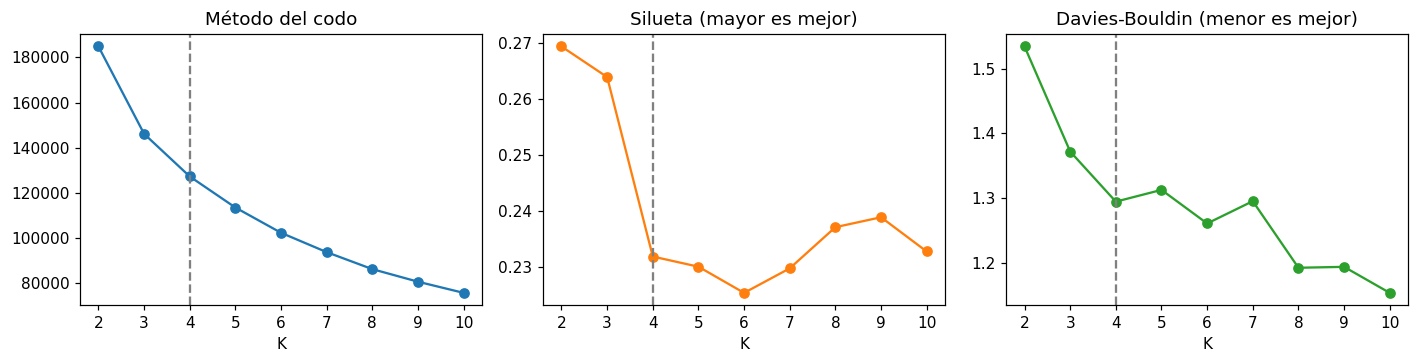

In [4]:
K_ELEGIDO = 4

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, y, titulo, color in [(axes[0], inercias, 'Método del codo', 'C0'),
                             (axes[1], siluetas, 'Silueta (mayor es mejor)', 'C1'),
                             (axes[2], davies, 'Davies-Bouldin (menor es mejor)', 'C2')]:
    ax.plot(list(K_RANGO), y, 'o-', color=color)
    ax.axvline(K_ELEGIDO, ls='--', color='gray')
    ax.set(xlabel='K', title=titulo, xticks=list(K_RANGO))
plt.tight_layout(); plt.show()

**Decisión sobre K:** los tres criterios no coinciden, y eso mismo es parte del resultado.

La silueta es máxima en K = 2, pero esa partición solo separa viajes cortos de viajes largos y no aporta nada que UrbanMove no sepa ya. Además, el valor absoluto es bajo (alrededor de 0.27), lo que indica que los viajes no forman grupos separados por espacios vacíos sino una nube continua: cualquier K impone cortes sobre un continuo.

El codo muestra que la inercia cae 21 % al pasar de 2 a 3 y 13 % al pasar de 3 a 4, y a partir de ahí cada cluster adicional aporta menos del 11 %. El índice Davies-Bouldin tiene un mínimo local en K = 4.

Se elige K = 4: es el punto donde el codo se aplana, donde Davies-Bouldin mejora frente a K = 3 y K = 5, y donde los perfiles resultantes son operativamente distintos (sección 6). Se deja constancia de que la silueta habría preferido K = 2.

In [5]:
kmeans = KMeans(n_clusters=K_ELEGIDO, init='k-means++', n_init=10, random_state=SEMILLA).fit(X)
muestra['cluster_km'] = kmeans.labels_
print(f'K elegido: {K_ELEGIDO}')
print(f'Silueta promedio: {silhouette_score(X[idx_sil], kmeans.labels_[idx_sil]):.4f}')
muestra.cluster_km.value_counts().sort_index().to_frame('viajes').assign(
    pct=lambda t: 100 * t.viajes / N)

K elegido: 4
Silueta promedio: 0.2318


,viajes,pct
cluster_km,,
0,9015,18.030
1,13474,26.948
2,13124,26.248
3,14387,28.774


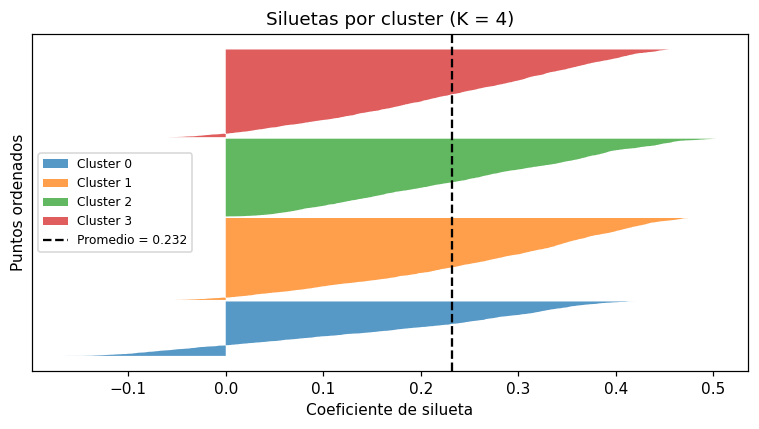

In [6]:
# Diagrama de silueta: muestra la calidad de cada cluster por separado
sil_vals = silhouette_samples(X[idx_sil], kmeans.labels_[idx_sil])
fig, ax = plt.subplots(figsize=(7, 4))
y = 0
for c in range(K_ELEGIDO):
    v = np.sort(sil_vals[kmeans.labels_[idx_sil] == c])
    ax.fill_betweenx(np.arange(y, y + len(v)), 0, v, alpha=0.75, label=f'Cluster {c}')
    y += len(v) + 50
ax.axvline(sil_vals.mean(), ls='--', color='k', label=f'Promedio = {sil_vals.mean():.3f}')
ax.set(xlabel='Coeficiente de silueta', ylabel='Puntos ordenados', title=f'Siluetas por cluster (K = {K_ELEGIDO})',
       yticks=[])
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 3. Clustering jerárquico (Ward)

El método de Ward empieza con cada viaje como su propio cluster y en cada paso une los dos grupos cuyo empalme aumenta menos la varianza interna. No necesita K de entrada: el corte del dendrograma define cuántos grupos quedan.

**Restricción práctica:** el algoritmo calcula distancias entre todos los pares, así que la memoria crece con el cuadrado del número de viajes. Con 50 000 viajes serían unos 1 250 millones de pares. Por eso se corre sobre una submuestra aleatoria de 5 000 viajes, que es suficiente para comparar la estructura de los grupos.

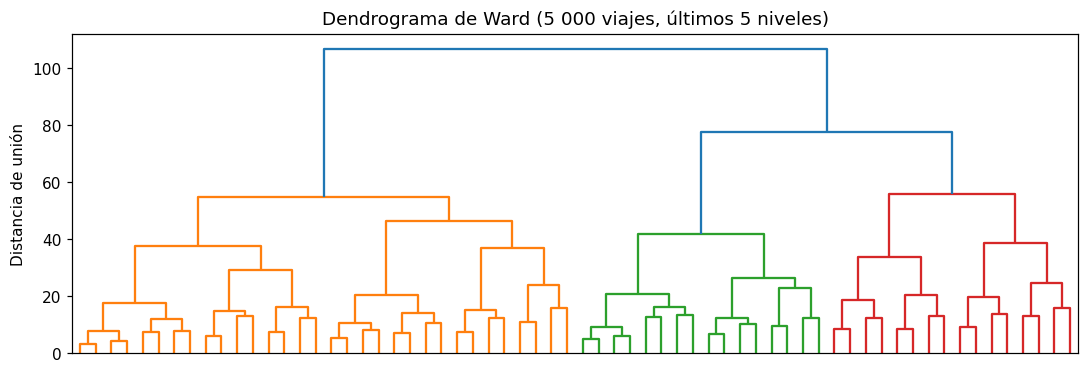

,clusters resultantes,altura de la unión,salto respecto a la siguiente
0,2,106.674,29.281
1,3,77.393,21.624
2,4,55.769,0.929
3,5,54.840,8.588
4,6,46.251,4.340
5,7,41.911,3.355
6,8,38.556,1.064
7,9,37.492,0.750
8,10,36.742,2.960
9,11,33.783,NaN


In [7]:
idx_ward = rng.choice(N, 5_000, replace=False)
X_ward = X[idx_ward]

enlaces = linkage(X_ward, method='ward')
fig, ax = plt.subplots(figsize=(10, 3.5))
dendrogram(enlaces, truncate_mode='level', p=5, no_labels=True, ax=ax, color_threshold=None)
ax.set(title='Dendrograma de Ward (5 000 viajes, últimos 5 niveles)', ylabel='Distancia de unión')
plt.tight_layout(); plt.show()

# Alturas de unión: un salto grande indica que unir esos grupos cuesta mucho
alturas = enlaces[-10:, 2][::-1]
pd.DataFrame({'clusters resultantes': range(2, 12), 'altura de la unión': alturas,
              'salto respecto a la siguiente': alturas - np.append(alturas[1:], np.nan)})

In [8]:
ward = AgglomerativeClustering(n_clusters=K_ELEGIDO, linkage='ward').fit(X_ward)
ari = adjusted_rand_score(kmeans.labels_[idx_ward], ward.labels_)
print(f'Silueta Ward:    {silhouette_score(X_ward, ward.labels_):.4f}')
print(f'Silueta K-means (mismos 5 000 viajes): {silhouette_score(X_ward, kmeans.labels_[idx_ward]):.4f}')
print(f'Índice Rand ajustado entre ambas particiones: {ari:.4f}')
pd.crosstab(pd.Series(kmeans.labels_[idx_ward], name='K-means'), pd.Series(ward.labels_, name='Ward'))

Silueta Ward:    0.1597
Silueta K-means (mismos 5 000 viajes): 0.2282
Índice Rand ajustado entre ambas particiones: 0.3580


Ward,0,1,2,3
K-means,,,,
0,878,4,6,7
1,153,321,4,860
2,284,653,354,22
3,272,136,1014,32


**Lectura:** Ward y K-means coinciden solo parcialmente: el índice Rand ajustado es 0.358 sobre los mismos 5 000 viajes, donde 1 sería coincidencia total y 0 coincidencia por azar. La tabla cruzada muestra dónde sí coinciden: el grupo de viajes largos de K-means (cluster 0) cae casi entero en un solo grupo de Ward (878 de 895 viajes). Los desacuerdos están en los viajes cortos, que Ward reparte de otra manera.

En calidad, K-means gana en las tres métricas sobre los mismos viajes (silueta 0.228 frente a 0.160). Es lo esperable: la silueta premia grupos esféricos y compactos, que es justo lo que K-means optimiza. El dendrograma muestra un salto grande de altura al pasar de 3 a 2 grupos (de 77 a 107), lo que confirma que la división más marcada del conjunto es entre viajes cortos y viajes largos.

**Implicación:** la partición operativa se toma de K-means; Ward sirve como verificación independiente de que el grupo de viajes largos es una estructura real y no un artefacto del algoritmo.

## 4. DBSCAN y detección de ruido

DBSCAN agrupa por densidad: un punto es núcleo si tiene al menos `min_samples` vecinos dentro de un radio épsilon. Los puntos que no alcanzan ningún núcleo quedan marcados como ruido con la etiqueta -1. A diferencia de K-means, no obliga a que todo viaje pertenezca a un grupo, que es justo lo que se necesita para detectar atípicos.

**Selección de min_samples:** una regla práctica es usar el doble de la dimensión, es decir 10 con cinco variables. Valores más altos hacen el algoritmo más conservador y marcan más ruido.

**Selección de épsilon con la gráfica k-distancia:** se calcula la distancia de cada punto a su vecino número k (k = min_samples - 1 = 9), se ordenan de menor a mayor y se grafican. La curva sube lentamente mientras se recorren puntos en zonas densas y se dispara cuando empiezan los puntos aislados. El codo de esa curva es el épsilon que separa densidad de aislamiento. Se ubica de forma objetiva como el punto más lejano a la recta que une los extremos de la curva.

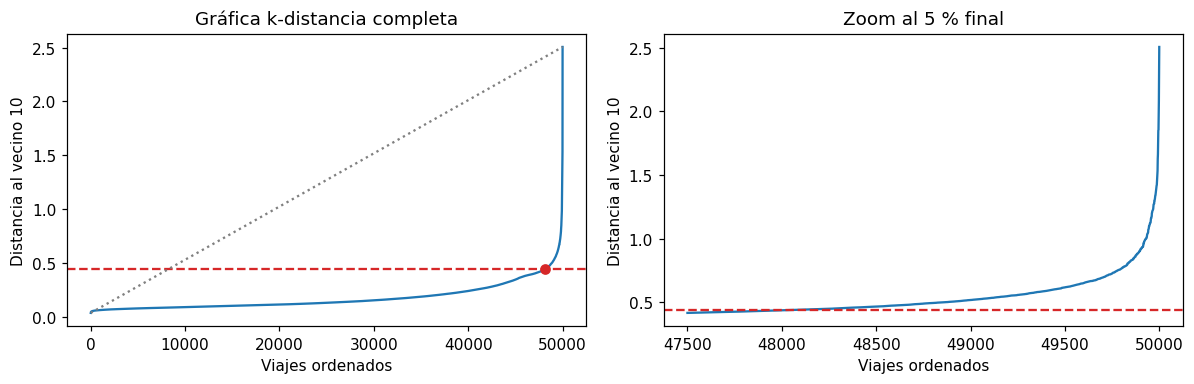

min_samples = 10 | épsilon elegido en el codo = 0.4395 (posición 48,092 de 50,000)


In [9]:
MIN_SAMPLES = 2 * len(VARIABLES)
vecinos = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
distancias = np.sort(vecinos.kneighbors(X)[0][:, -1])

# Codo objetivo: punto de la curva más alejado de la recta entre el primer y el último punto
x0 = np.arange(len(distancias))
p1, p2 = np.array([0, distancias[0]]), np.array([len(distancias) - 1, distancias[-1]])
v = p2 - p1
v = v / np.linalg.norm(v)
puntos = np.column_stack([x0, distancias]) - p1
dist_recta = np.abs(puntos[:, 0] * v[1] - puntos[:, 1] * v[0])
i_codo = int(np.argmax(dist_recta))
EPS = float(distancias[i_codo])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (ini, fin) in zip(axes, [(0, len(distancias)), (int(0.95 * len(distancias)), len(distancias))]):
    ax.plot(x0[ini:fin], distancias[ini:fin])
    ax.axhline(EPS, ls='--', color='C3')
    ax.set(xlabel='Viajes ordenados', ylabel=f'Distancia al vecino {MIN_SAMPLES}')
axes[0].plot([0, len(distancias) - 1], [distancias[0], distancias[-1]], ls=':', color='gray')
axes[0].scatter([i_codo], [EPS], color='C3', zorder=5)
axes[0].set_title('Gráfica k-distancia completa')
axes[1].set_title('Zoom al 5 % final')
plt.tight_layout(); plt.show()
print(f'min_samples = {MIN_SAMPLES} | épsilon elegido en el codo = {EPS:.4f} (posición {i_codo:,} de {N:,})')

In [10]:
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(X)
muestra['cluster_db'] = dbscan.labels_

etiquetas = pd.Series(dbscan.labels_)
n_clusters_db = etiquetas[etiquetas >= 0].nunique()
n_ruido = int((etiquetas == -1).sum())
print(f'Clusters encontrados: {n_clusters_db} | ruido: {n_ruido:,} viajes ({100*n_ruido/N:.2f} %)')
etiquetas.value_counts().head(8).to_frame('viajes').rename_axis('etiqueta')

Clusters encontrados: 2 | ruido: 842 viajes (1.68 %)


,viajes
etiqueta,
0,49151
-1,842
1,7


### 4.1 Sensibilidad de DBSCAN a épsilon

El resultado de DBSCAN depende por completo de épsilon, así que conviene mostrar cómo cambia alrededor del valor elegido en vez de presentarlo como si fuera único.

In [11]:
filas = []
for factor in [0.7, 0.85, 1.0, 1.15, 1.3]:
    e = EPS * factor
    lab = DBSCAN(eps=e, min_samples=MIN_SAMPLES).fit_predict(X)
    filas.append({'factor': factor, 'épsilon': e, 'clusters': len(set(lab)) - (1 if -1 in lab else 0),
                  '% ruido': 100 * np.mean(lab == -1)})
pd.DataFrame(filas)

,factor,épsilon,clusters,% ruido
0,0.700,0.308,53,7.700
1,0.850,0.374,34,4.682
2,1.000,0.439,2,1.684
3,1.150,0.505,5,0.840
4,1.300,0.571,1,0.462


### 4.2 ¿Qué son los viajes marcados como ruido?

El ruido solo es útil si se puede describir. Se comparan los viajes atípicos con el resto en las variables originales.

In [12]:
muestra['es_ruido'] = (muestra.cluster_db == -1)
comparacion = muestra.groupby('es_ruido')[['distancia_km', 'duracion_min', 'velocidad_kmh',
                                           'hora', 'passenger_count']].median()
comparacion.index = ['Viajes normales', 'Ruido DBSCAN']
display(comparacion)

print('Percentiles de los viajes de ruido:')
display(muestra[muestra.es_ruido][['distancia_km', 'duracion_min', 'velocidad_kmh']]
        .describe(percentiles=[0.1, 0.5, 0.9]).T)

print('Zonas de origen sobrerrepresentadas en el ruido:')
tasa = (muestra.groupby('zona_origen').es_ruido.mean() * 100).sort_values(ascending=False)
display(tasa.head(5).to_frame('% de viajes marcados como ruido'))

,distancia_km,duracion_min,velocidad_kmh,hora,passenger_count
Viajes normales,2.125,11.133,12.847,14.000,1.000
Ruido DBSCAN,3.449,10.125,36.892,10.000,1.000


Percentiles de los viajes de ruido:


,count,mean,std,min,10%,50%,90%,max
distancia_km,842.000,6.783,7.319,0.100,0.382,3.449,18.378,40.854
duracion_min,842.000,18.202,21.919,1.000,1.468,10.125,50.313,134.950
velocidad_kmh,842.000,31.426,16.561,0.107,2.629,36.892,47.911,68.709


Zonas de origen sobrerrepresentadas en el ruido:


,% de viajes marcados como ruido
zona_origen,
14,7.778
19,3.659
13,3.547
17,2.895
12,2.719


**Lectura:** DBSCAN marca 843 viajes como ruido, el 1.69 % de la muestra. No son errores de datos, porque la limpieza del notebook 00 ya los eliminó: son viajes reales con comportamiento extremo. Su velocidad mediana es 36.9 km/h frente a 12.8 km/h del resto, casi tres veces más, y su distribución tiene dos colas: el 10 % más corto recorre menos de 0.4 km y el 10 % más largo supera 18 km.

Por zona, el ruido se concentra en los aeropuertos y la periferia: el 7.8 % de los viajes que salen de JFK (zona 14) quedan marcados, frente al 3.5 % de LaGuardia (zona 13) y menos del 1 % en las zonas centrales de Manhattan. Son trayectos por autopista, rápidos y largos, que no se parecen a la operación urbana.

**Tratamiento operativo propuesto:**

1. Los viajes de aeropuerto salen del modelo general de estimación de tiempos y tarifas y pasan a un modelo propio, porque mezclarlos sesga los tiempos estimados del resto de la ciudad.
2. Los viajes muy cortos y lentos (menos de 0.4 km con varios minutos de duración) se marcan para revisión de facturación, porque suelen ser cancelaciones tardías o taxímetros mal cerrados.
3. El 1.69 % restante se conserva en la operación pero se excluye del entrenamiento de modelos predictivos, para que unos pocos casos extremos no dominen los ajustes.

## 5. Métricas de validación comparadas

Ninguna métrica sola decide: se reportan tres, que miden cosas distintas.

| Métrica | Qué mide | Dirección |
|---|---|---|
| Silueta | Separación entre clusters frente a cohesión interna | Mayor es mejor |
| Davies-Bouldin | Razón entre dispersión interna y distancia entre centroides | Menor es mejor |
| Calinski-Harabasz | Varianza entre clusters sobre varianza dentro de clusters | Mayor es mejor |

Para que la comparación sea justa, las tres se calculan sobre la misma submuestra de 10 000 viajes, y en DBSCAN se excluyen los puntos de ruido, porque no pertenecen a ningún grupo.

In [13]:
def metricas(X_eval, etiquetas_eval, nombre):
    validos = etiquetas_eval >= 0
    Xv, lv = X_eval[validos], etiquetas_eval[validos]
    if len(set(lv)) < 2:
        return {'método': nombre, 'clusters': len(set(lv)), 'silueta': np.nan,
                'Davies-Bouldin': np.nan, 'Calinski-Harabasz': np.nan, '% evaluado': 100 * validos.mean()}
    return {'método': nombre, 'clusters': len(set(lv)), 'silueta': silhouette_score(Xv, lv),
            'Davies-Bouldin': davies_bouldin_score(Xv, lv), 'Calinski-Harabasz': calinski_harabasz_score(Xv, lv),
            '% evaluado': 100 * validos.mean()}

X_eval = X[idx_sil]
tabla_val = pd.DataFrame([
    metricas(X_eval, kmeans.labels_[idx_sil], f'K-means (K={K_ELEGIDO})'),
    metricas(X_ward, ward.labels_, f'Ward (K={K_ELEGIDO}, 5 000 viajes)'),
    metricas(X_eval, dbscan.labels_[idx_sil], f'DBSCAN (eps={EPS:.3f})'),
]).set_index('método')
tabla_val.to_csv(f'{RUTA_DATOS}/metricas_rol2.csv')
tabla_val

,clusters,silueta,Davies-Bouldin,Calinski-Harabasz,% evaluado
método,,,,,
K-means (K=4),4,0.232,1.295,"3,216.131",100.000
"Ward (K=4, 5 000 viajes)",4,0.160,1.492,"1,184.110",100.000
DBSCAN (eps=0.439),2,0.251,0.598,2.543,98.190


**Lectura:** DBSCAN tiene el mejor Davies-Bouldin (0.598) y una silueta parecida a la de K-means, pero ese resultado es engañoso: encontró 2 clusters donde uno tiene 49 150 viajes y el otro apenas 7. El Calinski-Harabasz lo delata, con 2.5 frente a 3 216 de K-means. En este espacio de características DBSCAN no funciona como método de partición sino como detector de atípicos, que es el uso que se le da en la sección anterior.

Entre los dos métodos que sí particionan, K-means supera a Ward en las tres métricas. Los valores absolutos de silueta son bajos (alrededor de 0.23), lo que confirma que los viajes forman un continuo y no grupos separados por espacios vacíos. Es un hallazgo honesto: la segmentación es útil para operar, pero no describe fronteras naturales.

**Implicación:** se reporta K-means con K = 4 como partición operativa, DBSCAN como filtro de atípicos y Ward como verificación de estructura.

## 6. Perfiles operativos de K-means

Los centroides se devuelven a las unidades originales para poder leerlos. Cada fila describe un tipo de viaje real de la operación de UrbanMove.

In [14]:
centros = pd.DataFrame(escalador.inverse_transform(kmeans.cluster_centers_), columns=VARIABLES)
centros['distancia_km'] = np.expm1(centros.log_dist)
centros['duracion_min'] = np.expm1(centros.log_dur)
centros['hora aprox'] = (np.arctan2(centros.hora_sen, centros.hora_cos) * 24 / (2 * np.pi)) % 24

perfil = muestra.groupby('cluster_km').agg(
    viajes=('id', 'size'),
    distancia_mediana=('distancia_km', 'median'),
    duracion_mediana=('duracion_min', 'median'),
    velocidad_mediana=('velocidad_kmh', 'median'),
    pct_fin_semana=('fin_de_semana', lambda s: 100 * s.mean()),
    pct_ruido=('es_ruido', lambda s: 100 * s.mean()))
perfil['% de viajes'] = 100 * perfil.viajes / N
perfil['hora del centroide'] = centros['hora aprox'].round(1)
perfil['franja dominante'] = muestra.groupby('cluster_km').franja.agg(lambda s: s.value_counts().idxmax())
perfil['zona origen dominante'] = muestra.groupby('cluster_km').zona_origen.agg(lambda s: s.value_counts().idxmax())
perfil.to_csv(f'{RUTA_DATOS}/perfiles_rol2.csv')
perfil

,viajes,distancia_mediana,duracion_mediana,velocidad_mediana,pct_fin_semana,pct_ruido,% de viajes,hora del centroide,franja dominante,zona origen dominante
cluster_km,,,,,,,,,,
0,9015,8.340,23.700,21.809,31.015,4.626,18.030,22.400,noche,13
1,13474,1.538,8.283,11.619,24.662,1.254,26.948,9.500,valle,1
2,13124,2.270,14.683,9.618,26.745,0.571,26.248,16.000,pico_pm,0
3,14387,1.601,7.183,13.868,32.460,1.258,28.774,21.400,noche,2


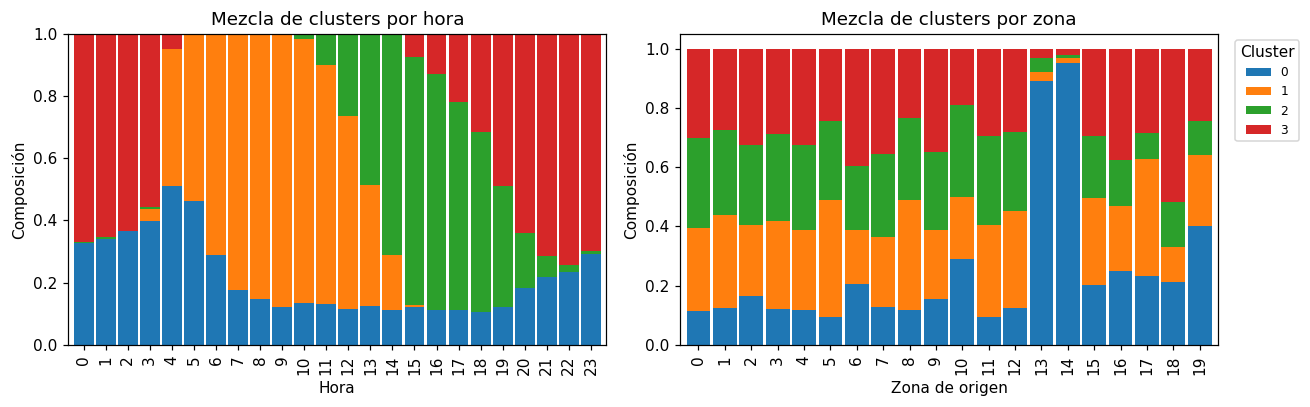

In [15]:
# Distribución de los clusters por hora y por zona
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
pd.crosstab(muestra.hora, muestra.cluster_km, normalize='index').plot(
    kind='bar', stacked=True, ax=axes[0], width=0.9, legend=False)
axes[0].set(xlabel='Hora', ylabel='Composición', title='Mezcla de clusters por hora')
pd.crosstab(muestra.zona_origen, muestra.cluster_km, normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1], width=0.9)
axes[1].set(xlabel='Zona de origen', ylabel='Composición', title='Mezcla de clusters por zona')
axes[1].legend(title='Cluster', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout(); plt.show()

**Lectura:** los cuatro perfiles son operativamente distintos:

| Cluster | Viajes | Perfil | Descripción |
|---|---|---|---|
| 0 | 18.0 % | Traslados largos | 8.3 km y 23.7 min a 21.8 km/h, zona dominante LaGuardia (13), concentrados de noche. Incluye el 4.6 % del ruido de DBSCAN |
| 1 | 26.9 % | Cortos de media mañana | 1.5 km en 8.3 min, centroide cerca de las 9:30, la menor proporción de fin de semana (24.7 %) |
| 2 | 26.2 % | Congestión de la tarde | 2.3 km pero 14.7 min, velocidad de 9.6 km/h, la más baja de los cuatro; franja dominante pico_pm |
| 3 | 28.8 % | Cortos nocturnos | 1.6 km en 7.2 min a 13.9 km/h, centroide alrededor de las 21:00 y la mayor proporción de fin de semana (32.5 %) |

La comparación entre los clusters 2 y 3 es la más útil para UrbanMove: recorren distancias parecidas (2.3 contra 1.6 km) pero el de la tarde tarda el doble. La diferencia no es el viaje, es el tráfico.

**Implicación:** el tiempo de servicio por viaje no puede estimarse con un promedio único. Un viaje de 2 km a las 17:00 y otro igual a las 21:00 ocupan al conductor durante tiempos muy distintos, y eso afecta tanto la tarifa como la cantidad de conductores necesarios por franja.

## 7. Exportación de etiquetas

El Rol 3 compara sus perfiles blandos con esta partición dura, y el Rol 4 usa el porcentaje de ruido en sus recomendaciones.

In [16]:
muestra[['id', 'cluster_km', 'cluster_db', 'es_ruido']].to_csv(f'{RUTA_DATOS}/etiquetas_rol2.csv', index=False)
resumen = pd.DataFrame([
    ('K-means', 'K elegido', f'{K_ELEGIDO} (silueta {tabla_val.iloc[0]["silueta"]:.3f})'),
    ('K-means', 'Criterio de selección', 'Codo de inercia y máximo de silueta entre K = 2 y 10'),
    ('Ward', 'Coincidencia con K-means', f'ARI = {ari:.3f} sobre 5 000 viajes'),
    ('DBSCAN', 'Parámetros', f'eps = {EPS:.3f} (codo de k-distancia), min_samples = {MIN_SAMPLES}'),
    ('DBSCAN', 'Clusters y ruido', f'{n_clusters_db} clusters, {100*n_ruido/N:.2f} % de ruido'),
], columns=['Método', 'Medida', 'Valor'])
resumen.to_csv(f'{RUTA_DATOS}/resultados_rol2.csv', index=False)
resumen

,Método,Medida,Valor
0,K-means,K elegido,4 (silueta 0.232)
1,K-means,Criterio de selección,Codo de inercia y máximo de silueta entre K = ...
2,Ward,Coincidencia con K-means,ARI = 0.358 sobre 5 000 viajes
3,DBSCAN,Parámetros,"eps = 0.439 (codo de k-distancia), min_samples..."
4,DBSCAN,Clusters y ruido,"2 clusters, 1.68 % de ruido"
